In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv('atm_cash_management_dataset.csv')
df.head()

,ATM_ID,Date,Day_of_Week,Time_of_Day,Total_Withdrawals,Total_Deposits,Location_Type,Holiday_Flag,Special_Event_Flag,Previous_Day_Cash_Level,Weather_Condition,Nearby_Competitor_ATMs,Cash_Demand_Next_Day
0,ATM_0041,2022-04-25,Monday,Morning,57450,9308,Standalone,0,0,112953,Rainy,5,44165
1,ATM_0007,2023-11-24,Friday,Morning,72845,17896,Supermarket,0,0,115348,Clear,0,41249
2,ATM_0014,2022-08-27,Saturday,Morning,42957,12712,Supermarket,0,0,90731,Cloudy,1,29901
3,ATM_0029,2023-08-27,Sunday,Evening,43014,1375,Mall,0,0,88754,Rainy,5,44155
4,ATM_0028,2022-12-15,Thursday,Evening,36379,2938,Bank Branch,0,0,129312,Snowy,0,29784


In [21]:
#cleaning
print(df.shape)
print(df.isnull().sum())
print(df.duplicated().sum())
df['Date'] = pd.to_datetime(df['Date'])
df.describe()

(5658, 13)
ATM_ID                     0
Date                       0
Day_of_Week                0
Time_of_Day                0
Total_Withdrawals          0
Total_Deposits             0
Location_Type              0
Holiday_Flag               0
Special_Event_Flag         0
Previous_Day_Cash_Level    0
Weather_Condition          0
Nearby_Competitor_ATMs     0
Cash_Demand_Next_Day       0
dtype: int64
0


,Date,Total_Withdrawals,Total_Deposits,Holiday_Flag,Special_Event_Flag,Previous_Day_Cash_Level,Nearby_Competitor_ATMs,Cash_Demand_Next_Day
count,5658,5658.000000,5658.000000,5658.000000,5658.000000,5658.000000,5658.000000,5658.000000
mean,2023-01-04 13:54:46.956521,49808.106928,10129.078473,0.022093,0.096501,100283.994698,2.477731,43085.207494
min,2022-01-01 00:00:00,1380.000000,0.000000,0.000000,0.000000,23266.000000,0.000000,0.000000
25%,2022-07-05 00:00:00,39469.250000,6765.000000,0.000000,0.000000,86533.500000,1.000000,31558.750000
50%,2023-01-06 00:00:00,50039.000000,10048.000000,0.000000,0.000000,100276.500000,2.000000,42589.500000
75%,2023-07-07 00:00:00,60132.500000,13430.000000,0.000000,0.000000,113956.500000,4.000000,53831.000000
max,2024-01-01 00:00:00,107790.000000,32395.000000,1.000000,1.000000,172227.000000,5.000000,114724.000000
std,NaN,14903.539241,4878.853583,0.146998,0.295303,20122.365608,1.719487,16797.100086


In [22]:
#grouping
print(df.groupby('Day_of_Week')['Total_Withdrawals'].mean())
print(df.groupby('Time_of_Day')['Total_Withdrawals'].mean())
print(df.groupby('Location_Type')['Total_Withdrawals'].mean())
print(df.groupby('Weather_Condition')['Total_Withdrawals'].mean())

Day_of_Week
Friday       49782.086797
Monday       48933.696751
Saturday     49504.024691
Sunday       50041.124079
Thursday     49980.465770
Tuesday      50419.633626
Wednesday    50036.903896
Name: Total_Withdrawals, dtype: float64
Time_of_Day
Afternoon    49487.113872
Evening      49818.557799
Morning      50178.944649
Night        49771.172073
Name: Total_Withdrawals, dtype: float64
Location_Type
Bank Branch    50445.065789
Gas Station    50035.090035
Mall           48623.035422
Standalone     49554.436953
Supermarket    50346.261715
Name: Total_Withdrawals, dtype: float64
Weather_Condition
Clear     50199.533016
Cloudy    49858.680055
Rainy     49771.974594
Snowy     49358.684488
Name: Total_Withdrawals, dtype: float64


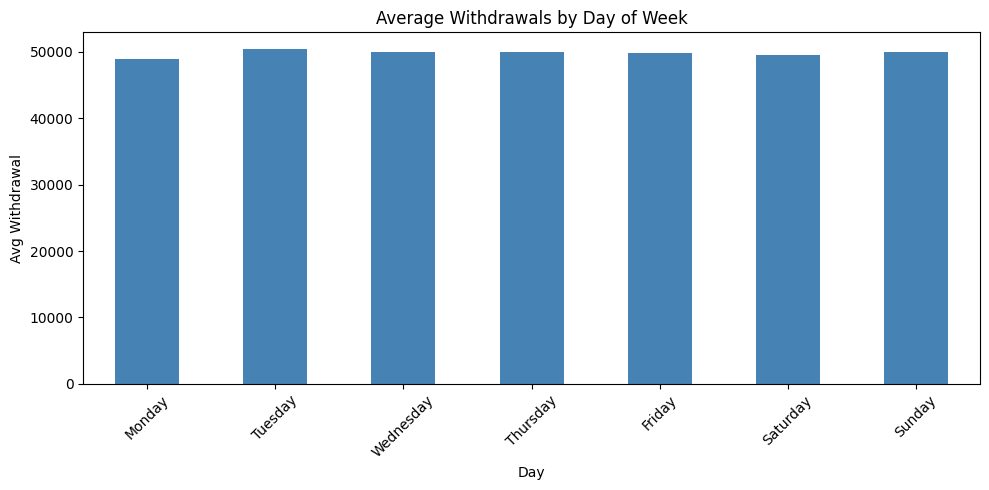

In [23]:
#bar_plot
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_data = df.groupby('Day_of_Week')['Total_Withdrawals'].mean().reindex(day_order)

plt.figure(figsize=(10,5))
day_data.plot(kind='bar', color='steelblue')
plt.title('Average Withdrawals by Day of Week')
plt.xlabel('Day')
plt.ylabel('Avg Withdrawal')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Monday has the lowest average withdrawals. Tuesday records the highest. Weekend usage remains close to weekday levels.

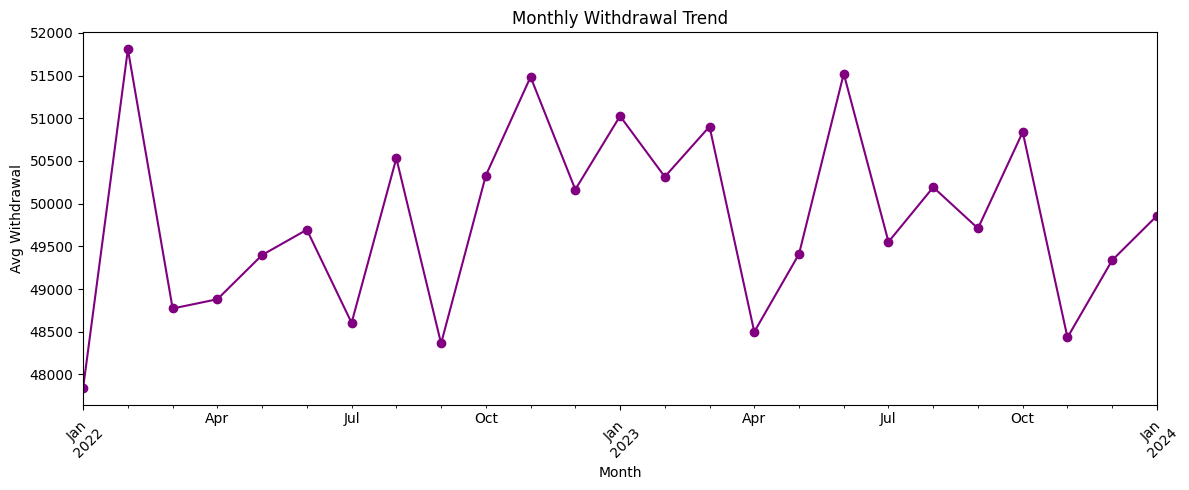

In [24]:
#line_plot
df['Month'] = df['Date'].dt.to_period('M')
monthly = df.groupby('Month')['Total_Withdrawals'].mean()

plt.figure(figsize=(12,5))
monthly.plot(kind='line', marker='o', color='purple')
plt.title('Monthly Withdrawal Trend')
plt.xlabel('Month')
plt.ylabel('Avg Withdrawal')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

No strong seasonal trend is observed. Withdrawals remain stable between 47,000 and 52,000 across January 2022 to January 2024.

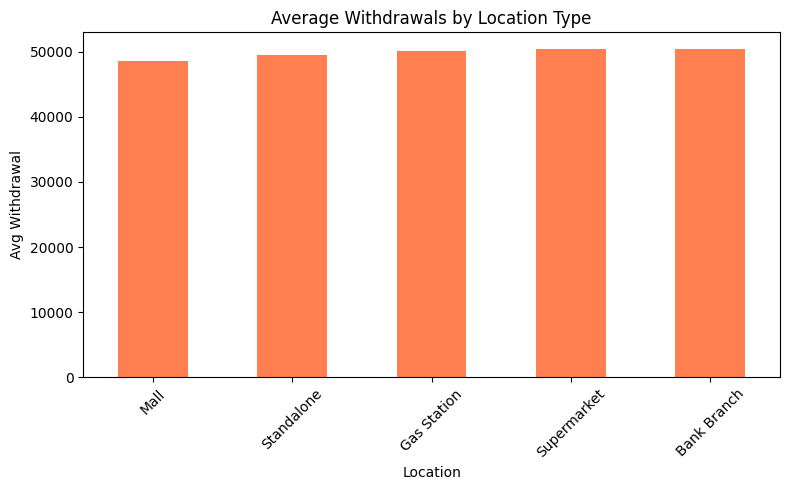

In [25]:
# bar_plot - by Location Type
loc_data = df.groupby('Location_Type')['Total_Withdrawals'].mean().sort_values()
plt.figure(figsize=(8,5))
loc_data.plot(kind='bar', color='coral')
plt.title('Average Withdrawals by Location Type')
plt.xlabel('Location')
plt.ylabel('Avg Withdrawal')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Bank Branch ATMs have the highest average withdrawals. Mall ATMs show the lowest, likely due to card-based payments being preferred there.

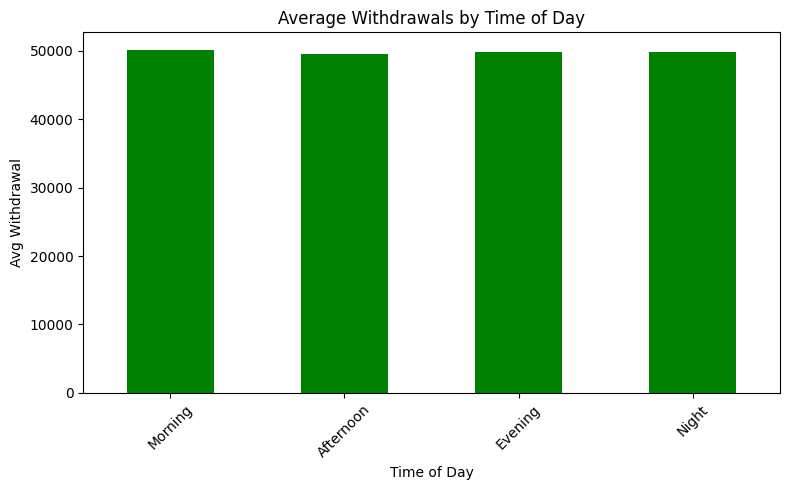

In [26]:
# bar_plot - by Time of Day
time_order = ['Morning', 'Afternoon', 'Evening', 'Night']
time_data = df.groupby('Time_of_Day')['Total_Withdrawals'].mean().reindex(time_order)

plt.figure(figsize=(8,5))
time_data.plot(kind='bar', color='green')
plt.title('Average Withdrawals by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Avg Withdrawal')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Morning is the peak time for ATM withdrawals. Afternoon sees the least activity across all time slots.